## Build and Train a PyTorch LSTM in Under 100 Lines of Code

https://www.youtube.com/watch?v=J_ksCv_r_rU

Dados

https://www.tensorflow.org/datasets/catalog/fashion_mnist?hl=pt-br

https://www.kaggle.com/datasets/zalando-research/fashionmnist

https://github.com/zalandoresearch/fashion-mnist

https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data

https://www.kaggle.com/code/shahad001/pytorch-with-fashionmnist-dataset

In [1]:
import tensorflow as tf

#(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

#print(f"Shape of x_train: {x_train.shape}")
#print(f"Shape of y_train: {y_train.shape}")
#print(f"Shape of x_test: {x_test.shape}")
#print(f"Shape of y_test: {y_test.shape}")



2025-09-21 22:21:26.366718: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-21 22:21:26.387841: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-21 22:21:26.412161: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-21 22:21:26.412193: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-21 22:21:26.424001: I tensorflow/core/platform/cpu_feature_gua

In [2]:
#!pip install torchvision


In [3]:
import os
import torch
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt

from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

Coleta dos dados FashionMNIST ==> https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html



In [4]:
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

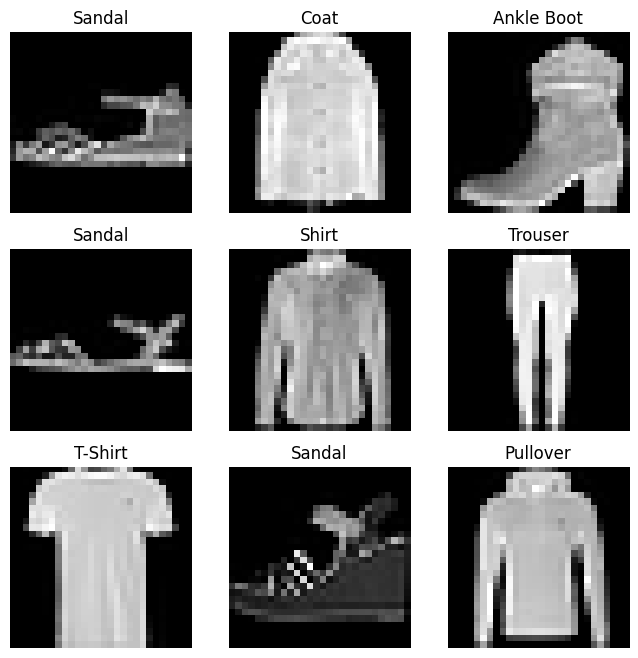

In [5]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [6]:
batchsize=100

#training_data = datasets.FashionMNIST(root="../fashion_mnist", train=True, transform=transforms.ToTensor())
#test_data= datasets.FashionMNIST(root="../fashion_mnist", train=True, transform=transforms.ToTensor())

In [7]:
training_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [8]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [9]:

batchsize=100

train_dataloader = DataLoader(training_data, batch_size= batchsize)
test_dataloader = DataLoader(test_data, batch_size= batchsize)

https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html

In [10]:
train_dataloader

In [11]:
# define hyperparmaters

sequence_len =28
input_len=28
hidden_size =128
num_layers=2
num_classes =10
num_epochs =5
learning_rate =0.01

In [12]:
# criar o LSTM

class LSTM_errado(nn.Module):
    def __init__(self,input_len, hidden_size, num_classes, num_layers):
       super(LSTM, self).__init__()
       self.hidden_size = hidden_size
       self.num_layers = num_layers
       self.lstm = nn.LSTM(input_len,hidden_size, num_layers, num_classes, batch_first= True)
       self.output_layers = nn.Linear(hidden_size, num_classes)
        
    def forward(self, X):
       hidden_states = torch.zeros(self.num_layers, X.size(0), self.hidden_size)
       cell_states = torch.zeros(self.num_layers, X.size(0), self.hidden_size)
       out, _ = self.lstm(X, (hidden_states, cell_states))
       out = self.output_layer(out[:,-1,:])
       return out
       
       
        

In [13]:
# correção
class LSTM(nn.Module):
    def __init__(self, input_len, hidden_size, num_classes, num_layers):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # CORRECTED: removed 'num_classes' from nn.LSTM arguments
        self.lstm = nn.LSTM(input_len, hidden_size, num_layers, batch_first=True)
        
        # Corrected variable name: output_layer instead of output_layers
        self.output_layer = nn.Linear(hidden_size, num_classes)
        
    def forward(self, X):
        hidden_states = torch.zeros(self.num_layers, X.size(0), self.hidden_size)
        cell_states = torch.zeros(self.num_layers, X.size(0), self.hidden_size)
        
        out, _ = self.lstm(X, (hidden_states, cell_states))
        
        # CORRECTED variable name: output_layer instead of output_layers
        out = self.output_layer(out[:, -1, :])
        
        return out

In [14]:
model = LSTM(input_len, hidden_size, num_classes, num_layers)
print(model)
       

LSTM(
  (lstm): LSTM(28, 128, num_layers=2, batch_first=True)
  (output_layer): Linear(in_features=128, out_features=10, bias=True)
)


In [15]:
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [16]:
adam = optim.Adam(model.parameters(), lr=learning_rate)

In [17]:
def train(num_epochs, model, train_dataloader, loss_func, adam):
    total_steps = len(train_dataloader)
    
    
    for epoch in range(num_epochs):
        for batch, (images, labels) in enumerate(train_dataloader):        
            images = images.reshape(-1, sequence_len, input_len)
            #device= "cuda" or 'ms1
            #labels = labels.to(device)
            output = model(images)
            loss = loss_func(output, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            if (batch+1)%100 ==0:
                print (f"Epoch {epoch+1}; Batch {batch+1}/{total_steps}; Loss:{loss.item():>4f}")
            

In [18]:
train(num_epochs, model, train_dataloader,loss_func,adam)

Epoch 1; Batch 100/600; Loss:2.297436
Epoch 1; Batch 200/600; Loss:2.300727
Epoch 1; Batch 300/600; Loss:2.289878
Epoch 1; Batch 400/600; Loss:2.294451
Epoch 1; Batch 500/600; Loss:2.294778
Epoch 1; Batch 600/600; Loss:2.282397
Epoch 2; Batch 100/600; Loss:2.281099
Epoch 2; Batch 200/600; Loss:2.284231
Epoch 2; Batch 300/600; Loss:2.269309
Epoch 2; Batch 400/600; Loss:2.268523
Epoch 2; Batch 500/600; Loss:2.268931
Epoch 2; Batch 600/600; Loss:2.253509
Epoch 3; Batch 100/600; Loss:2.240619
Epoch 3; Batch 200/600; Loss:2.245421
Epoch 3; Batch 300/600; Loss:2.210585
Epoch 3; Batch 400/600; Loss:2.191792
Epoch 3; Batch 500/600; Loss:2.182866
Epoch 3; Batch 600/600; Loss:2.154588
Epoch 4; Batch 100/600; Loss:2.088208
Epoch 4; Batch 200/600; Loss:2.093746
Epoch 4; Batch 300/600; Loss:1.990177
Epoch 4; Batch 400/600; Loss:1.897111
Epoch 4; Batch 500/600; Loss:1.843484
Epoch 4; Batch 600/600; Loss:1.839492
Epoch 5; Batch 100/600; Loss:1.731761
Epoch 5; Batch 200/600; Loss:1.806852
Epoch 5; Bat

In [19]:

test_images,test_labels = next(iter(test_dataloader))
test_images, '***', test_labels

(tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000

In [20]:
test_output = model(test_images.view(-1,28,28))

In [21]:
predicted = torch.max(test_output,1)

In [22]:
predicted

torch.return_types.max(
values=tensor([2.2365, 1.9766, 2.6803, 2.6574, 1.4820, 2.3812, 1.0745, 1.6468, 1.9164,
        2.2381, 1.5970, 2.1967, 2.0835, 2.6657, 2.0384, 2.6039, 1.2343, 1.8041,
        1.7453, 2.0292, 1.5949, 2.0836, 2.0382, 2.3315, 2.6408, 1.3387, 1.9484,
        2.5250, 2.0628, 2.2779, 1.8951, 1.6294, 2.3568, 2.4519, 1.9683, 1.5470,
        1.9984, 1.9598, 2.1390, 2.0784, 2.0625, 2.6607, 1.9556, 2.0125, 2.0111,
        2.1855, 2.0118, 2.5942, 1.4403, 1.9399, 1.9095, 1.1839, 1.6977, 2.0451,
        1.5286, 1.8146, 1.2165, 1.9117, 1.6501, 1.2190, 2.2366, 2.1931, 1.4118,
        2.0536, 2.7225, 2.3933, 1.8816, 2.6227, 1.7103, 1.8460, 1.9402, 0.6586,
        1.9265, 1.7647, 1.9619, 2.0734, 2.7589, 1.9407, 2.0827, 1.9921, 2.1107,
        1.6028, 2.2105, 1.8924, 2.2309, 2.3186, 2.5875, 2.0361, 2.3319, 2.0111,
        2.2352, 1.9875, 1.9555, 1.8723, 2.7327, 1.6074, 1.6157, 2.5942, 2.0571,
        1.8833], grad_fn=<MaxBackward0>),
indices=tensor([7, 2, 1, 1, 2, 1, 4, 2, 7, 7, 2

In [23]:
# #percentage_correct = 0 + 1 if predicted[i] == test_labels[i] for i in range(100)

In [24]:
predicted_uni = torch.max(test_output,1)[1]
predicted_uni


tensor([7, 2, 1, 1, 2, 1, 4, 2, 7, 7, 2, 7, 7, 1, 4, 1, 8, 2, 9, 0, 2, 7, 7, 7,
        1, 2, 4, 3, 7, 3, 2, 4, 1, 3, 4, 0, 7, 7, 7, 9, 3, 1, 0, 7, 4, 7, 4, 1,
        4, 4, 2, 2, 7, 2, 4, 2, 9, 4, 9, 0, 7, 7, 8, 7, 1, 1, 1, 1, 7, 2, 7, 4,
        2, 0, 4, 1, 1, 2, 9, 2, 1, 8, 7, 9, 7, 3, 3, 4, 3, 2, 7, 1, 4, 7, 1, 9,
        0, 1, 2, 2])

In [25]:

correct = [ 1 for i in range(100) if predicted_uni[i] == test_labels[i] ]

percentage_correct = sum(correct)/100


percentage_correct

0.44

In [26]:
def test_loop(dataloader,model, loss_fn, optimizer):
   size = len(dataloader.dataset)
   num_batches = len(dataloader)
   test_loss, correct = 0,0
   
   with torch.no_grad():
      for X,y in dataloader:
        # reshape images      
        X=X.reshape(-1,28,28)
        pred = model(X)
        test_loss += loss_fn(pred,y).item()
        correct += (pred.argmax(1) ==y).type(torch.float).sum().item()
        
   test_loss /= num_batches
   correct /=size
   
   print(f"Test Error:\n Accuracy: {(100*correct):>0.1f}%, Avg Loss: {test_loss:>8f}\n")
   return 100*correct

In [27]:
test_dataloader

In [28]:
test_loop(test_dataloader, model, loss_func, adam)

Test Error:
 Accuracy: 42.8%, Avg Loss: 1.509568



42.84